# **Projet 4 - Analyse des causes d'attrition au sein d'une ESN**

> - Réaliser une analyse exploratoire des données afin d'identifier les principales tendances et différences entre les employés.
> - Identifier les facteurs potentiellement associés à l'attrition des employés.
> - Préparer et nettoyer les données afin de construire un jeu de données centralisé et exploitable pour la modélisation.
> - Comparer plusieurs modèles de classification supervisée afin de prédire le risque d'attrition.
> - Identifier les variables ayant le plus d'influence sur l'attrition des employés.

## **Contexte**

> -  Une entreprise de services du numérique (ESN) souhaite mieux comprendre les facteurs associés au départ de ses employés.
> - L'entreprise dispose de plusieurs fichiers de données contenant des informations sur les employés, leur situation professionnelle et leurs caractéristiques.
> - L'objectif est d'explorer et de croiser ces données afin d'identifier les principales tendances associées à l'attrition et de préparer les données pour la modélisation prédictive.

 ## **Objectif**
> - Identifier les principaux facteurs associés à l'attrition des employés afin de mieux comprendre les causes de départ au sein de l'ESN et de construire un modèle permettant de prédire le risque d'attrition.

## **Objectifs Data**

> - **E4 - Améliorer l'approche de classification :** comparer les modèles, améliorer les performances et sélectionner l'approche de classification la plus pertinente.

## **ÉTAPE 4 - Améliorer l'approche de classification**

### **Importation des librairies**

In [18]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "imbalanced-learn"
])

0

In [19]:
# Importation des librairies

import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Équilibrage des classes
from imblearn.over_sampling import SMOTE

print("Importation des librairies OK")

Importation des librairies OK


In [24]:
# Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_validate,
    StratifiedKFold
)

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

# Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

print("Importation des modules OK")

Importation des modules OK


### **Chargement des jeux des données**

In [7]:
# Importation du fichier central

df_modelisation = pd.read_csv("../data/processed/df_modelisation.csv", index_col=0)

print("Importation du fichier central OK")
print(f"Dimensions du dataset : {df_modelisation.shape[0]} lignes, {df_modelisation.shape[1]} colonnes")

display(df_modelisation.head())

Importation du fichier central OK
Dimensions du dataset : 1470 lignes, 46 colonnes


,nominal__genre_M,nominal__statut_marital_Célibataire,nominal__statut_marital_Divorcé(e),nominal__statut_marital_Marié(e),nominal__departement_Commercial,nominal__departement_Consulting,nominal__departement_Ressources Humaines,nominal__poste_Assistant de Direction,nominal__poste_Cadre Commercial,nominal__poste_Consultant,...,remainder__satisfaction_employee_equipe,remainder__satisfaction_employee_equilibre_pro_perso,remainder__note_evaluation_actuelle,remainder__augementation_salaire_precedente,remainder__nombre_participation_pee,remainder__nb_formations_suivies,remainder__distance_domicile_travail,remainder__niveau_education,remainder__annees_depuis_la_derniere_promotion,a_quitte_l_entreprise
nominal__genre_F,,,,,,,,,,,,,,,,,,,,,
1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,3.0,11.0,0.0,0.0,1.0,2.0,0.0,Oui
0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,4.0,3.0,4.0,23.0,1.0,3.0,8.0,1.0,1.0,Non
0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,2.0,3.0,3.0,15.0,0.0,3.0,2.0,2.0,0.0,Oui
1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,...,3.0,3.0,3.0,11.0,0.0,3.0,3.0,4.0,3.0,Non
0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,4.0,3.0,3.0,12.0,1.0,3.0,2.0,1.0,2.0,Non


### **Définition de l'approche de modélisation**

> - L'objectif est d'améliorer la prédiction de l'Attrition en tenant compte du **déséquilibre des classes** et du **contexte métier**.
>
> L'approche retenue :
>
> - Séparer les données en jeux d'apprentissage et de test avec une **stratification** de la variable cible.
> - Réaliser du **feature engineering** pour enrichir les données.
> - Tester un **modèle non-linéaire** avec `class_weight` pour gérer le déséquilibre des classes.
> - Évaluer le modèle par **validation croisée stratifiée** avec la Precision, le Recall, le F1-score et le ROC-AUC.
> - Utiliser la **courbe Precision-Recall** pour déterminer le seuil de classification adapté au contexte métier.
> - Tester, si nécessaire, des méthodes d'**undersampling ou d'oversampling**.
> - Évaluer et interpréter le modèle final sur le **jeu de test**.

### **Séparation stratifiée des données**

> - Les données sont séparées en jeux d'apprentissage et de test avec une **stratification de la variable cible** afin de conserver la proportion des classes.

In [8]:
# Séparation de la variable cible et des features

X = df_modelisation.drop(columns="a_quitte_l_entreprise")
y = df_modelisation["a_quitte_l_entreprise"]

# Séparation stratifiée des jeux d'apprentissage et de test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1176, 45)
X_test  : (294, 45)
y_train : (1176,)
y_test  : (294,)


In [9]:
# Vérification de la stratification

print("Distribution de la cible dans le dataset complet :")
print(y.value_counts(normalize=True))

print("\nDistribution dans le jeu d'apprentissage :")
print(y_train.value_counts(normalize=True))

print("\nDistribution dans le jeu de test :")
print(y_test.value_counts(normalize=True))

Distribution de la cible dans le dataset complet :
a_quitte_l_entreprise
Non    0.838776
Oui    0.161224
Name: proportion, dtype: float64

Distribution dans le jeu d'apprentissage :
a_quitte_l_entreprise
Non    0.838435
Oui    0.161565
Name: proportion, dtype: float64

Distribution dans le jeu de test :
a_quitte_l_entreprise
Non    0.840136
Oui    0.159864
Name: proportion, dtype: float64


### **Feature Engineering**

> - De nouvelles variables sont créées à partir des données existantes afin de mieux représenter la **satisfaction**, l'**évolution professionnelle** et l'**expérience du salarié**.

#### **Feature 1 - Satisfaction moyenne** (évaluation actuelle − évaluation précédente)

> - Combine les quatre dimensions de satisfaction du salarié en calculant leur **moyenne** : `(satisfaction environnement + satisfaction nature du travail + satisfaction équipe + satisfaction équilibre pro/perso) / 4`. Une valeur plus faible peut ainsi être associée à un risque d'Attrition plus élevé.

In [10]:
# Création de la satisfaction moyenne

satisfaction_cols = [
    "remainder__satisfaction_employee_environnement",
    "remainder__satisfaction_employee_nature_travail",
    "remainder__satisfaction_employee_equipe",
    "remainder__satisfaction_employee_equilibre_pro_perso"
]

X_train["satisfaction_moyenne"] = X_train[satisfaction_cols].mean(axis=1)
X_test["satisfaction_moyenne"] = X_test[satisfaction_cols].mean(axis=1)

print("Feature créée :", "satisfaction_moyenne")
print(X_train["satisfaction_moyenne"].describe())

Feature créée : satisfaction_moyenne
count    1176.000000
mean        2.733206
std         0.510303
min         1.250000
25%         2.500000
50%         2.750000
75%         3.000000
max         4.000000
Name: satisfaction_moyenne, dtype: float64


#### **Feature 2 - Évolution de l'évaluation**

> - Calculer la différence entre sa note actuelle et sa note précédente : `note_evaluation_actuelle - note_evaluation_precedente`. Une valeur positive indique une amélioration, une valeur négative une diminution et une valeur nulle une évaluation stable.

In [11]:
# Création de l'évolution de l'évaluation

X_train["evolution_evaluation"] = (
    X_train["remainder__note_evaluation_actuelle"]
    - X_train["remainder__note_evaluation_precedente"]
)

X_test["evolution_evaluation"] = (
    X_test["remainder__note_evaluation_actuelle"]
    - X_test["remainder__note_evaluation_precedente"]
)

print("Feature créée :", "evolution_evaluation")
print(X_train["evolution_evaluation"].describe())

Feature créée : evolution_evaluation
count    1176.000000
mean        0.420068
std         0.808722
min        -1.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         3.000000
Name: evolution_evaluation, dtype: float64


> - La nouvelle variable présente une moyenne de **0,42**, indiquant une progression moyenne des évaluations. La médiane de **0** montre que l'évaluation est restée stable pour une grande partie des salariés, tandis que les valeurs allant de **-1 à +3** indiquent respectivement des diminutions et des progressions de l'évaluation.

#### **Feature 3 - Expérience avant l'entreprise** (annee_experience_totale - annees_dans_l_entreprise)

> - Cette feature estime l'**expérience professionnelle acquise avant l'entreprise** en calculant la différence entre l'expérience professionnelle totale et les années passées dans l'entreprise.

In [12]:
# Création de l'expérience professionnelle avant l'entreprise

X_train["experience_avant_entreprise"] = (
    X_train["remainder__annee_experience_totale"]
    - X_train["remainder__annees_dans_l_entreprise"]
)

X_test["experience_avant_entreprise"] = (
    X_test["remainder__annee_experience_totale"]
    - X_test["remainder__annees_dans_l_entreprise"]
)

print("Feature créée :", "experience_avant_entreprise")
print(X_train["experience_avant_entreprise"].describe())

Feature créée : experience_avant_entreprise
count    1176.000000
mean        4.314626
std         6.261098
min         0.000000
25%         0.000000
50%         2.000000
75%         5.000000
max        31.000000
Name: experience_avant_entreprise, dtype: float64


> - La nouvelle variable présente une moyenne de **4,31 années** d'expérience acquises avant l'entreprise. La médiane de **2 années** montre que la majorité des salariés possède une expérience préalable relativement faible, tandis que certaines valeurs atteignent **31 années**.

#### **Feature 4 - Déplacement × Distance** (distance domicile-travail × fréquence de déplacement)

> - Cette feature combine la **distance domicile-travail** et la **fréquence des déplacements** afin de créer un indicateur de la charge potentielle liée aux déplacements. Plus la distance et la fréquence sont élevées, plus l'impact des déplacements est important.

In [13]:
# Création du poids associé à la fréquence des déplacements

poids_deplacement_train = (
    X_train["nominal__frequence_deplacement_Occasionnel"]
    + 2 * X_train["nominal__frequence_deplacement_Frequent"]
)

poids_deplacement_test = (
    X_test["nominal__frequence_deplacement_Occasionnel"]
    + 2 * X_test["nominal__frequence_deplacement_Frequent"]
)

# Création de la feature d'interaction

X_train["impact_deplacement"] = (
    X_train["remainder__distance_domicile_travail"]
    * poids_deplacement_train
)

X_test["impact_deplacement"] = (
    X_test["remainder__distance_domicile_travail"]
    * poids_deplacement_test
)

print("Feature créée :", "impact_deplacement")
print(X_train["impact_deplacement"].describe())

Feature créée : impact_deplacement
count    1176.000000
mean       10.231293
std        11.495238
min         0.000000
25%         2.000000
50%         7.000000
75%        15.000000
max        58.000000
Name: impact_deplacement, dtype: float64


> - La nouvelle variable présente une moyenne de **10,23**, avec une médiane de **7**. Les valeurs vont de **0 à 58**, ce qui permet de distinguer les salariés ayant une faible charge de déplacement de ceux combinant une distance importante et des déplacements fréquents.

#### **Feature 5 — Impact Augmentation salariale × Équilibre pro/perso**

> - Cette feature combine l'**augmentation salariale précédente** et la **satisfaction liée à l'équilibre professionnel/personnel** afin d'identifier une éventuelle interaction entre la progression salariale et l'équilibre de vie du salarié.

In [14]:
# Création de la feature d'interaction

X_train["impact_augmentation_equilibre"] = (
    X_train["remainder__augementation_salaire_precedente"]
    * X_train["remainder__satisfaction_employee_equilibre_pro_perso"]
)

X_test["impact_augmentation_equilibre"] = (
    X_test["remainder__augementation_salaire_precedente"]
    * X_test["remainder__satisfaction_employee_equilibre_pro_perso"]
)

print("Feature créée :", "impact_augmentation_equilibre")
print(X_train["impact_augmentation_equilibre"].describe())

Feature créée : impact_augmentation_equilibre
count    1176.000000
mean       41.982993
std        15.057497
min        11.000000
25%        33.000000
50%        39.000000
75%        51.000000
max       100.000000
Name: impact_augmentation_equilibre, dtype: float64


> - La nouvelle variable présente une moyenne de **41,98** et une médiane de **39**. Les valeurs vont de **11 à 100**, permettant de représenter l'interaction entre le niveau d'augmentation salariale et la satisfaction liée à l'équilibre professionnel/personnel.

### **Modèle non-linéaire et gestion du déséquilibre**

#### **Random Forest**

> - Nous utilisons un **Random Forest** afin de modéliser des relations non linéaires et de prendre en compte le **déséquilibre des classes** grâce à `class_weight="balanced"`.

In [15]:
# Création du modèle Random Forest

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

# Entraînement du modèle

rf_model.fit(X_train, y_train)

print("Modèle Random Forest entraîné avec succès.")

Modèle Random Forest entraîné avec succès.


#### **Validation croisée stratifiée**

##### **Résultats par Fold**

In [22]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [23]:

# Validation croisée stratifiée

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Listes pour stocker les métriques de chaque Fold

precision_scores = []
recall_scores = []
f1_scores = []
roc_auc_scores = []

# Validation croisée

for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train), 1):

    X_fold_train = X_train.iloc[train_index]
    X_fold_val = X_train.iloc[val_index]

    y_fold_train = y_train.iloc[train_index]
    y_fold_val = y_train.iloc[val_index]

    # Entraînement du modèle
    rf_model.fit(X_fold_train, y_fold_train)

    # Prédictions
    y_pred = rf_model.predict(X_fold_val)

    # Probabilité de la classe "Oui"
    index_oui = list(rf_model.classes_).index("Oui")
    y_pred_proba = rf_model.predict_proba(X_fold_val)[:, index_oui]

    # Calcul des métriques
    precision_scores.append(
        precision_score(y_fold_val, y_pred, pos_label="Oui")
    )

    recall_scores.append(
        recall_score(y_fold_val, y_pred, pos_label="Oui")
    )

    f1_scores.append(
        f1_score(y_fold_val, y_pred, pos_label="Oui")
    )

    roc_auc_scores.append(
        roc_auc_score(y_fold_val, y_pred_proba)
    )

    print(f"Fold {fold} terminé.")

Fold 1 terminé.
Fold 2 terminé.
Fold 3 terminé.
Fold 4 terminé.
Fold 5 terminé.


> - Les performances obtenues sur chaque Fold sont comparées à l'aide de la **moyenne** et de l'**écart-type** afin d'évaluer la stabilité et la capacité de généralisation du modèle.

##### **Moyenne et écart-type des métriques**

In [ ]:
# Calcul de la moyenne et de l'écart-type des métriques

resultats_cv = pd.DataFrame({
    "Precision": precision_scores,
    "Recall": recall_scores,
    "F1-score": f1_scores,
    "ROC-AUC": roc_auc_scores
})

print("Résultats par Fold :")
display(resultats_cv)

print("\nMoyenne :")
display(resultats_cv.mean())

print("\nÉcart-type :")
display(resultats_cv.std())

Résultats par Fold :


,Precision,Recall,F1-score,ROC-AUC
0,0.666667,0.315789,0.428571,0.790736
1,0.625000,0.263158,0.370370,0.809444
2,0.760000,0.500000,0.603175,0.856933
3,0.789474,0.394737,0.526316,0.890395
4,0.571429,0.526316,0.547945,0.776717



Moyenne :


Precision    0.682514
Recall       0.400000
F1-score     0.495275
ROC-AUC      0.824845
dtype: float64


Écart-type :


Precision    0.091301
Recall       0.113799
F1-score     0.094115
ROC-AUC      0.047548
dtype: float64

#### **Courbe Precision-Recall et choix du seuil**

##### **Courbe Precision-Recall**

> - Permet d'analyser le compromis entre la précision et le rappel selon différents seuils de classification. Elle sera utilisée pour identifier un seuil adapté à la détection de l'Attrition.

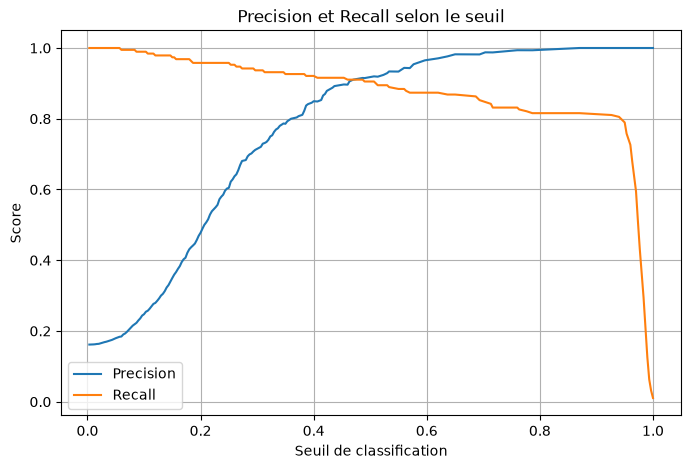

In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Probabilités de la classe "Oui"

index_oui = list(rf_model.classes_).index("Oui")
y_proba = rf_model.predict_proba(X_train)[:, index_oui]

# Calcul de la courbe Precision-Recall

precision, recall, thresholds = precision_recall_curve(
    y_train,
    y_proba,
    pos_label="Oui"
)

# Visualisation

plt.figure(figsize=(8, 5))

plt.plot(
    thresholds,
    precision[:-1],
    label="Precision"
)

plt.plot(
    thresholds,
    recall[:-1],
    label="Recall"
)

plt.xlabel("Seuil de classification")
plt.ylabel("Score")
plt.title("Precision et Recall selon le seuil")
plt.legend()
plt.grid()

plt.show()

> - La courbe **Precision-Recall** montre comment les performances du modèle changent lorsque le **seuil de classification** varie.
> - Lorsque le seuil augmente, la **précision augmente**, mais le **rappel diminue**.
> - Il faut donc trouver un **équilibre entre les deux métriques** afin de mieux détecter les salariés susceptibles de quitter l'entreprise.

#### **Évaluation finale sur le jeu de test**

> - Le modèle final est évalué sur le **jeu de test** avec le seuil de classification de **0,65** défini précédemment.
> - Les performances sont analysées à l'aide de la **précision, du rappel, du F1-score et de la matrice de confusion**.

In [ ]:
# Prédiction des probabilités sur le jeu de test

index_oui = list(rf_model.classes_).index("Oui")

y_test_proba = rf_model.predict_proba(X_test)[:, index_oui]

# Application du seuil optimal

y_test_pred = np.where(
    y_test_proba >= best_threshold,
    "Oui",
    "Non"
)

# Calcul des métriques

precision_test = precision_score(
    y_test,
    y_test_pred,
    pos_label="Oui"
)

recall_test = recall_score(
    y_test,
    y_test_pred,
    pos_label="Oui"
)

f1_test = f1_score(
    y_test,
    y_test_pred,
    pos_label="Oui"
)

roc_auc_test = roc_auc_score(
    (y_test == "Oui").astype(int),
    y_test_proba
)

print(f"Precision : {precision_test:.3f}")
print(f"Recall    : {recall_test:.3f}")
print(f"F1-score  : {f1_test:.3f}")
print(f"ROC-AUC   : {roc_auc_test:.3f}")

Precision : 0.600
Recall    : 0.128
F1-score  : 0.211
ROC-AUC   : 0.812


#### **Prédictions Out-of-Fold**

> - Les prédictions sont réalisées avec une **validation croisée stratifiée**.
> - Chaque observation est prédite par un modèle qui ne l'a pas utilisée pour son apprentissage.
> - Ces prédictions permettent de choisir un seuil de classification plus fiable avant l'évaluation finale sur le jeu de test.

In [ ]:
# Création de la validation croisée stratifiée

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Tableau pour stocker les probabilités Out-of-Fold

y_train_oof_proba = np.zeros(len(X_train))

# Validation croisée

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_train, y_train),
    start=1
):
    
    X_fold_train = X_train.iloc[train_idx]
    X_fold_val = X_train.iloc[val_idx]
    
    y_fold_train = y_train.iloc[train_idx]
    
    # Création du modèle
    rf_oof = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42
    )
    
    # Entraînement
    rf_oof.fit(X_fold_train, y_fold_train)
    
    # Probabilité de la classe "Oui"
    index_oui = list(rf_oof.classes_).index("Oui")
    
    y_train_oof_proba[val_idx] = (
        rf_oof.predict_proba(X_fold_val)[:, index_oui]
    )

    print(f"Fold {fold} terminé.")

print("Prédictions Out-of-Fold terminées.")

Fold 1 terminé.
Fold 2 terminé.
Fold 3 terminé.
Fold 4 terminé.
Fold 5 terminé.
Prédictions Out-of-Fold terminées.


#### **Courbe Precision-Recall avec les prédictions Out-of-Fold**

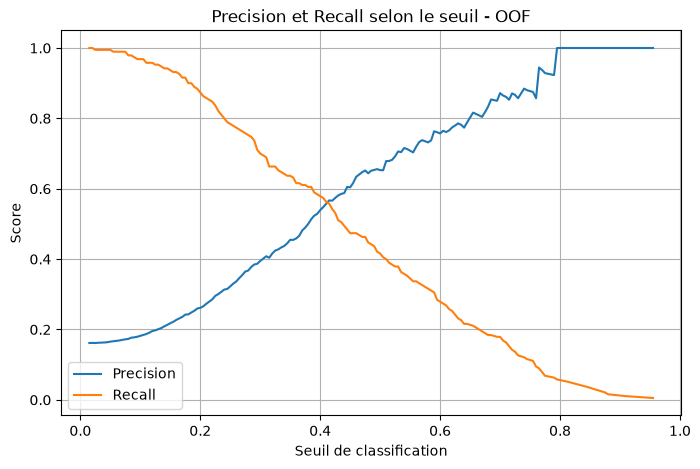

In [ ]:
# Calcul de la courbe Precision-Recall avec les prédictions OOF

precision_oof, recall_oof, thresholds_oof = precision_recall_curve(
    y_train,
    y_train_oof_proba,
    pos_label="Oui"
)

# Visualisation

plt.figure(figsize=(8, 5))

plt.plot(
    thresholds_oof,
    precision_oof[:-1],
    label="Precision"
)

plt.plot(
    thresholds_oof,
    recall_oof[:-1],
    label="Recall"
)

plt.xlabel("Seuil de classification")
plt.ylabel("Score")
plt.title("Precision et Recall selon le seuil - OOF")
plt.legend()
plt.grid()

plt.show()

#### **Détermination du seuil optimal**

> - Nous calculons le **F1-score** pour chaque seuil à partir des prédictions Out-of-Fold.
> - Le seuil qui maximise le F1-score sera retenu afin de trouver un équilibre entre la précision et le rappel.

In [ ]:
# Calcul du F1-score pour chaque seuil

f1_scores_oof = (
    2 * precision_oof[:-1] * recall_oof[:-1]
    / (precision_oof[:-1] + recall_oof[:-1] + 1e-10)
)

# Recherche du meilleur seuil

index_best_threshold_oof = np.argmax(f1_scores_oof)

best_threshold_oof = thresholds_oof[index_best_threshold_oof]
best_precision_oof = precision_oof[index_best_threshold_oof]
best_recall_oof = recall_oof[index_best_threshold_oof]
best_f1_oof = f1_scores_oof[index_best_threshold_oof]

print(f"Seuil optimal : {best_threshold_oof:.3f}")
print(f"Precision      : {best_precision_oof:.3f}")
print(f"Recall         : {best_recall_oof:.3f}")
print(f"F1-score       : {best_f1_oof:.3f}")

Seuil optimal : 0.415
Precision      : 0.567
Recall         : 0.558
F1-score       : 0.562


> - Le seuil optimal obtenu avec les prédictions **Out-of-Fold** est de **0,415**.
> - Avec ce seuil, le modèle obtient une **précision de 56,7 %**, un **rappel de 55,8 %** et un **F1-score de 56,2 %**.
> - Ce seuil offre un meilleur équilibre entre la détection des cas d'Attrition et la limitation des faux positifs.

### **Entraînement du modèle final**

> - Le modèle final est réentraîné sur l'ensemble du **jeu d'apprentissage**.
> - Le paramètre `class_weight="balanced"` permet de mieux prendre en compte le déséquilibre des classes.
> - Le seuil de classification retenu est de **0,415**, déterminé à partir des prédictions Out-of-Fold.

In [ ]:
# Entraînement du modèle final sur tout le jeu d'apprentissage

rf_final = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_final.fit(X_train, y_train)

print("Modèle final entraîné sur X_train.")

Modèle final entraîné sur X_train.


### **Évaluation finale sur le jeu de test**

> - Le modèle final est évalué sur le **jeu de test**, jamais utilisé pendant l'apprentissage.
> - Le seuil de **0,415** est appliqué pour classer les salariés selon leur risque d'Attrition.
> - Les performances sont évaluées avec la **précision, le rappel, le F1-score et le ROC-AUC**.

In [ ]:
# Prédiction des probabilités sur le jeu de test

index_oui = list(rf_final.classes_).index("Oui")

y_test_proba = rf_final.predict_proba(X_test)[:, index_oui]

# Application du seuil optimal

y_test_pred = np.where(
    y_test_proba >= best_threshold_oof,
    "Oui",
    "Non"
)

# Calcul des métriques

precision_test = precision_score(
    y_test,
    y_test_pred,
    pos_label="Oui"
)

recall_test = recall_score(
    y_test,
    y_test_pred,
    pos_label="Oui"
)

f1_test = f1_score(
    y_test,
    y_test_pred,
    pos_label="Oui"
)

roc_auc_test = roc_auc_score(
    (y_test == "Oui").astype(int),
    y_test_proba
)

print(f"Precision : {precision_test:.3f}")
print(f"Recall    : {recall_test:.3f}")
print(f"F1-score  : {f1_test:.3f}")
print(f"ROC-AUC   : {roc_auc_test:.3f}")

Precision : 0.434
Recall    : 0.489
F1-score  : 0.460
ROC-AUC   : 0.789


> - Sur le jeu de test, le modèle obtient une **précision de 43,4 %**, un **rappel de 48,9 %**, un **F1-score de 46,0 %** et un **ROC-AUC de 78,9 %**.
> - Le ROC-AUC montre une capacité correcte à distinguer les salariés avec et sans Attrition.
> - La performance diminue par rapport aux résultats obtenus en validation croisée, ce qui montre une généralisation plus modérée sur les données jamais vues.

### **Matrice de confusion**

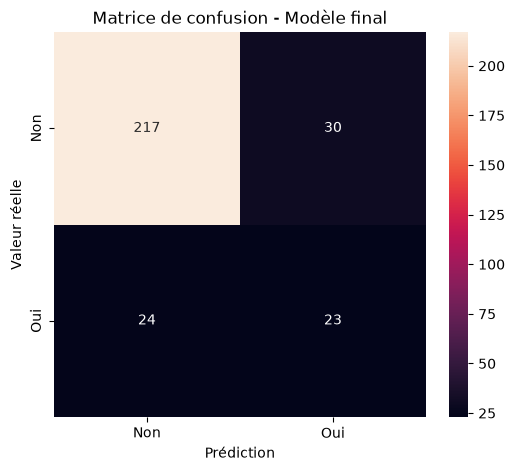

In [ ]:
# Calcul de la matrice de confusion

cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=["Non", "Oui"]
)

# Affichage

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Non", "Oui"],
    yticklabels=["Non", "Oui"]
)

plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.title("Matrice de confusion - Modèle final")
plt.show()

> - Le modèle identifie correctement **217 salariés sans Attrition** et **23 salariés avec Attrition**.
> - Il produit **30 faux positifs** et **24 faux négatifs**.
> - Dans le contexte métier, les faux négatifs sont importants car ils correspondent à des salariés à risque d'Attrition qui ne sont pas détectés.
> - Le modèle détecte donc environ **la moitié des cas réels d'Attrition**, ce qui montre une marge d'amélioration.

### **Équilibrage des classes avec SMOTE**

> - La classe `Oui` est minoritaire dans notre jeu de données.
> - Nous utilisons **SMOTE** pour créer de nouvelles observations synthétiques de cette classe dans le jeu d'apprentissage.
> - L'objectif est d'améliorer la détection des cas d'Attrition et notamment le **rappel**.
> - Le rééquilibrage est réalisé uniquement sur le jeu d'apprentissage afin d'éviter toute fuite de données.

In [ ]:
# Création du SMOTE
smote = SMOTE(random_state=42)

# Rééquilibrage uniquement du jeu d'apprentissage
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Avant SMOTE :")
print(y_train.value_counts())

print("\nAprès SMOTE :")
print(y_train_smote.value_counts())

Avant SMOTE :
a_quitte_l_entreprise
Non    986
Oui    190
Name: count, dtype: int64

Après SMOTE :
a_quitte_l_entreprise
Non    986
Oui    986
Name: count, dtype: int64


In [ ]:
# Entraînement du modèle avec les données équilibrées

rf_smote = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

rf_smote.fit(X_train_smote, y_train_smote)

print("Modèle Random Forest entraîné avec SMOTE.")

Modèle Random Forest entraîné avec SMOTE.


In [ ]:
# Prédictions sur le jeu de test original

y_test_pred_smote = rf_smote.predict(X_test)

# Probabilité de la classe "Oui"
index_oui_smote = list(rf_smote.classes_).index("Oui")
y_test_proba_smote = rf_smote.predict_proba(X_test)[:, index_oui_smote]

# Calcul des métriques
precision_test_smote = precision_score(
    y_test,
    y_test_pred_smote,
    pos_label="Oui"
)

recall_test_smote = recall_score(
    y_test,
    y_test_pred_smote,
    pos_label="Oui"
)

f1_test_smote = f1_score(
    y_test,
    y_test_pred_smote,
    pos_label="Oui"
)

roc_auc_test_smote = roc_auc_score(
    (y_test == "Oui").astype(int),
    y_test_proba_smote
)

print(f"Precision : {precision_test_smote:.3f}")
print(f"Recall    : {recall_test_smote:.3f}")
print(f"F1-score  : {f1_test_smote:.3f}")
print(f"ROC-AUC   : {roc_auc_test_smote:.3f}")

Precision : 0.769
Recall    : 0.213
F1-score  : 0.333
ROC-AUC   : 0.802


> - Le SMOTE équilibre les classes **Non** et **Oui** dans le jeu d'apprentissage.
> - Le modèle est évalué sur le **jeu de test original**.
> - La précision augmente de **0,434 à 0,769**, mais le rappel diminue de **0,489 à 0,213**.
> - Le **F1-score diminue** de 0,460 à 0,333.
> - Le modèle initial reste donc préférable pour détecter l'Attrition.

> - L'utilisation de SMOTE permet d'améliorer la Precision et légèrement le ROC-AUC.
> - Cependant, le Recall et le F1-score diminuent fortement. Dans notre contexte métier, cette baisse est importante car l'objectif est d'identifier les salariés susceptibles de quitter l'entreprise.
> - Le modèle avec SMOTE risque donc de manquer davantage de cas d'Attrition. Malgré une meilleure Precision, il est moins adapté à notre objectif.
> - Nous retenons donc le modèle initial avec `class_weight="balanced"` comme modèle final.

### **Comparaison des modèles**

In [ ]:
# Comparaison des modèles

comparaison_modeles = pd.DataFrame({
    "Métrique": ["Precision", "Recall", "F1-score", "ROC-AUC"],
    "Modèle initial": [
        precision_test,
        recall_test,
        f1_test,
        roc_auc_test
    ],
    "Avec SMOTE": [
        precision_test_smote,
        recall_test_smote,
        f1_test_smote,
        roc_auc_test_smote
    ]
})

print(comparaison_modeles)

    Métrique  Modèle initial  Avec SMOTE
0  Precision        0.433962    0.769231
1     Recall        0.489362    0.212766
2   F1-score        0.460000    0.333333
3    ROC-AUC        0.788612    0.801533


> - Le modèle initial obtient de meilleurs résultats en **Recall** et en **F1-score**.
> - SMOTE améliore légèrement le **ROC-AUC**, mais diminue fortement le Recall et le F1-score.
> - Pour notre objectif de mieux détecter les cas **"Oui"**, nous retenons donc **le modèle initial**.

In [ ]:
# Probabilité d'attrition
probabilite_attrition = rf_final.predict_proba(X_test)[:, index_oui]

# Classification avec le seuil optimal
prediction_finale = np.where(
    probabilite_attrition >= best_threshold_oof,
    "Oui",
    "Non"
)

# Création du tableau des résultats
resultats_attrition = pd.DataFrame({
    "id_employee": X_test.index,
    "Probabilité d'attrition": probabilite_attrition,
    "Prédiction": prediction_finale
})

# Affichage
resultats_attrition

,id_employee,Probabilité d'attrition,Prédiction
0,1.0,0.485,Oui
1,1.0,0.135,Non
2,0.0,0.165,Non
3,0.0,0.070,Non
4,0.0,0.365,Non
...,...,...,...
289,0.0,0.080,Non
290,0.0,0.070,Non
291,0.0,0.470,Oui
292,1.0,0.195,Non


In [ ]:
# Probabilité d'attrition sur le jeu de test

index_oui = list(rf_final.classes_).index("Oui")

probabilite_attrition = rf_final.predict_proba(X_test)[:, index_oui]

# Conversion en pourcentage
probabilite_attrition_pct = probabilite_attrition * 100

# Classification avec le seuil optimal

prediction_finale = np.where(
    probabilite_attrition >= best_threshold_oof,
    "Oui",
    "Non"
)

# Récupération des identifiants

employee_ids = (
    df_modelisation.loc[X_test.index, "id_employee"]
    if "df_modelisation" in globals() and "id_employee" in df_modelisation.columns
    else X_test.index
)

# Création du tableau des résultats

resultats_attrition = pd.DataFrame({
    "id_employee": employee_ids,
    "Probabilité d'attrition (%)": probabilite_attrition_pct,
    "Prédiction": prediction_finale
})

# Affichage

resultats_attrition

,id_employee,Probabilité d'attrition (%),Prédiction
0,1.0,48.5,Oui
1,1.0,13.5,Non
2,0.0,16.5,Non
3,0.0,7.0,Non
4,0.0,36.5,Non
...,...,...,...
289,0.0,8.0,Non
290,0.0,7.0,Non
291,0.0,47.0,Oui
292,1.0,19.5,Non


### **Interprétation métier**

In [ ]:
# Synthèse des performances des modèles

synthese_modeles = pd.DataFrame({
    "Modèle": [
        "Dummy",
        "Régression logistique",
        "Random Forest final",
        "Random Forest + SMOTE"
    ],
    
    "Accuracy": [
        0.840,
        0.857,
        np.nan,
        np.nan
    ],
    
    "Precision": [
        np.nan,
        0.593,
        precision_test,
        precision_test_smote
    ],
    
    "Recall Oui": [
        np.nan,
        0.340,
        recall_test,
        recall_test_smote
    ],
    
    "F1-score Oui": [
        np.nan,
        0.430,
        f1_test,
        f1_test_smote
    ],
    
    "ROC-AUC": [
        np.nan,
        np.nan,
        roc_auc_test,
        roc_auc_test_smote
    ]
})

# Affichage en pourcentage
synthese_modeles.style.format({
    "Accuracy": "{:.1%}",
    "Precision": "{:.1%}",
    "Recall Oui": "{:.1%}",
    "F1-score Oui": "{:.1%}",
    "ROC-AUC": "{:.1%}"
})

,Modèle,Accuracy,Precision,Recall Oui,F1-score Oui,ROC-AUC
0,Dummy,84.0%,nan%,nan%,nan%,nan%
1,Régression logistique,85.7%,59.3%,34.0%,43.0%,nan%
2,Random Forest final,nan%,43.4%,48.9%,46.0%,78.9%
3,Random Forest + SMOTE,nan%,76.9%,21.3%,33.3%,80.2%


In [17]:
# Comparaison finale des modèles

synthese_modeles = pd.DataFrame({
    "Modèle": [
        "Dummy",
        "Régression logistique",
        "Random Forest final",
        "Random Forest + SMOTE"
    ],

    "Accuracy": [
        0.840,
        0.857,
        0.816,
        np.nan
    ],

    "Precision": [
        np.nan,
        0.593,
        0.434,
        0.769
    ],

    "Recall Oui": [
        np.nan,
        0.340,
        0.489,
        0.213
    ],

    "F1-score Oui": [
        np.nan,
        0.430,
        0.460,
        0.333
    ],

    "ROC-AUC": [
        np.nan,
        np.nan,
        0.789,
        0.802
    ]
})

# Affichage en pourcentage

synthese_modeles.style.format({
    "Accuracy": "{:.1%}",
    "Precision": "{:.1%}",
    "Recall Oui": "{:.1%}",
    "F1-score Oui": "{:.1%}",
    "ROC-AUC": "{:.1%}"
})

,Modèle,Accuracy,Precision,Recall Oui,F1-score Oui,ROC-AUC
0,Dummy,84.0%,nan%,nan%,nan%,nan%
1,Régression logistique,85.7%,59.3%,34.0%,43.0%,nan%
2,Random Forest final,81.6%,43.4%,48.9%,46.0%,78.9%
3,Random Forest + SMOTE,nan%,76.9%,21.3%,33.3%,80.2%


> - Le modèle cherche à identifier les employés qui pourraient **quitter l'entreprise**.
> - Le **Recall** est important, car il permet de détecter davantage de cas d'attrition.
> - Le modèle initial présente un meilleur équilibre entre **Precision, Recall et F1-score** que le modèle avec SMOTE.
> - Les résultats montrent que le modèle peut aider à **identifier les profils à risque**, mais ses performances restent limitées.
> - Les faux négatifs sont particulièrement importants dans ce contexte, car ils correspondent à des salariés à risque qui ne seraient pas identifiés par le modèle.
> - Les prédictions doivent donc être utilisées comme **un outil d'aide à la décision**, et non comme une décision automatique.

### **Impact du déséquilibre des classes**


> - La classe **Oui** étant minoritaire, l'**Accuracy seule peut être trompeuse** : le modèle Dummy atteint déjà 84 % en privilégiant la classe majoritaire.
> - Le **Recall de la classe Oui** est donc particulièrement important pour mesurer la capacité à détecter les situations d'Attrition.
> - Le **ROC-AUC** permet d'évaluer la capacité de discrimination du modèle, mais doit également être interprété avec prudence en contexte déséquilibré.
> - La **courbe Precision-Recall** et le choix du seuil optimal sont donc utilisés en complément pour mieux répondre à l'objectif métier.

### **Conclusion**

> - Le **Random Forest avec pondération des classes** est retenu comme modèle final.
> - Le **feature engineering** et la gestion du déséquilibre ont été testés afin d'améliorer les performances.
> - Le seuil optimal de **0,415** a été déterminé à partir des prédictions **Out-of-Fold**.
> - Le modèle permet d'estimer une **probabilité d'Attrition pour chaque salarié**, mais ses prédictions doivent être utilisées comme un **outil d'aide à la décision**.

### **Sauvegarde du jeu des données**

In [ ]:
# Export des résultats d'attrition

resultats_attrition.to_csv(
    "../data/processed/resultats_attrition.csv",
    index=False
)

print("Résultats exportés avec succès.")